# Final Evaluation - CatBoost


## 1. Zielsetzung und methodische Einordnung

Nach Abschluss der Modellauswahl und Modellinterpretation wird das festgelegte getunte CatBoost-Modell abschließend auf dem bislang unangetasteten Testdatensatz August 2026 evaluiert. Hierzu werden Training und Validation aus den Monaten November 2025 bis Juli 2026 zu einem finalen Trainingsdatensatz zusammengeführt.

Die Modellkonfiguration, Feature-Auswahl und CatBoost-Aufbereitung wurden vor Betrachtung des August-Testdatensatzes festgelegt. Der August-Testdatensatz wird nicht für Hyperparameterwahl, Feature-Auswahl, Modellauswahl oder erneutes Tuning verwendet.

Alle drei Splits basieren auf der aktualisierten temporalen Split-Logik. Fahrten, deren `concrete_ride_id` über eine Split-Grenze läuft, wurden vor der Feature-Erstellung aus den Modellierungsdaten ausgeschlossen und werden nicht in Training, Validation oder Test verwendet.

## 2. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


PROJECT_DIR = Path.cwd()

while not (PROJECT_DIR / "datasets").exists():
    if PROJECT_DIR == PROJECT_DIR.parent:
        raise FileNotFoundError("Could not find project directory with datasets/.")
    PROJECT_DIR = PROJECT_DIR.parent

FEATURE_DIR = PROJECT_DIR / "datasets" / "modeling" / "features"
TRAIN_PATH = FEATURE_DIR / "train_features.parquet"
VALIDATION_PATH = FEATURE_DIR / "validation_features.parquet"
TEST_PATH = FEATURE_DIR / "test_features.parquet"

TRAIN_PERIOD = "November 2025 bis Juni 2026"
VALIDATION_PERIOD = "Juli 2026"
TEST_PERIOD = "August 2026"
FINAL_TRAIN_PERIOD = "November 2025 bis Juli 2026"

## 3. Daten laden


In [2]:
train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALIDATION_PATH)
test = pd.read_parquet(TEST_PATH)

dataset_overview = pd.DataFrame(
    {
        "Dataset": ["Training", "Validation", "Test"],
        "Period": [TRAIN_PERIOD, VALIDATION_PERIOD, TEST_PERIOD],
        "Observations": [len(train), len(validation), len(test)],
    }
)

dataset_overview

,Dataset,Period,Observations
0,Training,November 2025 bis Juni 2026,689684
1,Validation,Juli 2026,73867
2,Test,August 2026,85799


## 4. Finalen Trainingsdatensatz November 2025 bis Juli 2026 erstellen


In [3]:
final_train = pd.concat(
    [train, validation],
    ignore_index=True,
)

final_train_overview = pd.DataFrame(
    {
        "Dataset": ["Final Training", "Test"],
        "Period": [FINAL_TRAIN_PERIOD, TEST_PERIOD],
        "Observations": [len(final_train), len(test)],
    }
)

final_train_overview

,Dataset,Period,Observations
0,Final Training,November 2025 bis Juli 2026,763551
1,Test,August 2026,85799


## 5. Features und CatBoost-Aufbereitung

Die Feature-Auswahl entspricht Notebook 01 und Notebook 02. Es werden ausschließlich die zwölf externen bzw. exogenen Features verwendet. Strukturelle Bahnmerkmale werden nicht als Modellfeatures verwendet.

`event_hour`, `event_weekday` und `rr_precipitation_form` werden als kategoriale CatBoost-Features behandelt. Fehlende Werte dieser kategorialen Features werden als `"missing"` gesetzt und anschließend als Strings übergeben. Numerische Missing Values werden nicht vorab imputiert; CatBoost verarbeitet sie direkt.

In [4]:
external_features = [
    "event_hour",
    "event_weekday",
    "is_public_holiday",
    "ff_wind_speed_ms",
    "wind_direction_sin",
    "wind_direction_cos",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
    "rr_precipitation_form",
]

categorical_features = [
    "event_hour",
    "event_weekday",
    "rr_precipitation_form",
]

numeric_features = [
    feature for feature in external_features if feature not in categorical_features
]

X_final_train = final_train[external_features].copy()
X_test = test[external_features].copy()

y_final_train = final_train["delay_target"]
y_test = test["delay_target"]

X_final_train_catboost = X_final_train.copy()
X_test_catboost = X_test.copy()

for column in categorical_features:
    X_final_train_catboost[column] = (
        X_final_train_catboost[column].fillna("missing").astype(str)
    )
    X_test_catboost[column] = X_test_catboost[column].fillna("missing").astype(str)

feature_overview = pd.DataFrame(
    {
        "Feature": external_features,
        "Feature Type": [
            "categorical" if feature in categorical_features else "numeric"
            for feature in external_features
        ],
        "CatBoost Handling": [
            "native categorical" if feature in categorical_features else "numeric/raw"
            for feature in external_features
        ],
        "Missing Final Training": [
            X_final_train_catboost[feature].isna().sum() for feature in external_features
        ],
        "Missing Test": [
            X_test_catboost[feature].isna().sum() for feature in external_features
        ],
    }
)

feature_overview

,Feature,Feature Type,CatBoost Handling,Missing Final Training,Missing Test
0,event_hour,categorical,native categorical,0,0
1,event_weekday,categorical,native categorical,0,0
2,is_public_holiday,numeric,numeric/raw,0,0
3,ff_wind_speed_ms,numeric,numeric/raw,4806,0
4,wind_direction_sin,numeric,numeric/raw,4233,0
5,wind_direction_cos,numeric,numeric/raw,4233,0
6,fx_wind_gust_ms,numeric,numeric/raw,4806,0
7,tu_temperature_c,numeric,numeric/raw,1494,0
8,tu_relative_humidity_pct,numeric,numeric/raw,1575,0
9,rr_precipitation_mm,numeric,numeric/raw,326,0


## 6. Baselines auf November 2025 bis Juli 2026 fitten

Die Median- und Mean-Baseline werden ausschließlich auf dem finalen Trainingsdatensatz November 2025 bis Juli 2026 gefittet und anschließend auf August bewertet.

In [5]:
X_final_train_dummy = np.zeros((len(final_train), 1))
X_test_dummy = np.zeros((len(test), 1))

median_baseline = DummyRegressor(strategy="median")
median_baseline.fit(X_final_train_dummy, y_final_train)
median_baseline_predictions = median_baseline.predict(X_test_dummy)
median_baseline_mae = mean_absolute_error(y_test, median_baseline_predictions)
median_baseline_rmse = np.sqrt(mean_squared_error(y_test, median_baseline_predictions))
median_baseline_r2 = r2_score(y_test, median_baseline_predictions)

mean_baseline = DummyRegressor(strategy="mean")
mean_baseline.fit(X_final_train_dummy, y_final_train)
mean_baseline_predictions = mean_baseline.predict(X_test_dummy)
mean_baseline_mae = mean_absolute_error(y_test, mean_baseline_predictions)
mean_baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline_predictions))
mean_baseline_r2 = r2_score(y_test, mean_baseline_predictions)

baseline_performance = pd.DataFrame(
    [
        {
            "Model": "Median Baseline",
            "MAE": median_baseline_mae,
            "RMSE": median_baseline_rmse,
            "R2": median_baseline_r2,
        },
        {
            "Model": "Mean Baseline",
            "MAE": mean_baseline_mae,
            "RMSE": mean_baseline_rmse,
            "R2": mean_baseline_r2,
        },
    ]
)

baseline_performance.round(4)

,Model,MAE,RMSE,R2
0,Median Baseline,5.0875,10.1707,-0.1490
1,Mean Baseline,5.8890,9.4895,-0.0002


## 7. Finales CatBoost-Modell trainieren

Das finale CatBoost-Modell verwendet die bereits vor der August-Auswertung festgelegten Hyperparameter. In diesem Notebook findet keine erneute Hyperparameteroptimierung statt.

In [6]:
catboost_final_params = {
    "iterations": 300,
    "depth": 6,
    "learning_rate": 0.015,
    "l2_leaf_reg": 10,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0,
    "allow_writing_files": False,
}

final_train_pool = Pool(
    X_final_train_catboost,
    y_final_train,
    cat_features=categorical_features,
)
test_pool = Pool(
    X_test_catboost,
    y_test,
    cat_features=categorical_features,
)

final_catboost_model = CatBoostRegressor(**catboost_final_params)
final_catboost_model.fit(final_train_pool)

catboost_final_params

{'iterations': 300,
 'depth': 6,
 'learning_rate': 0.015,
 'l2_leaf_reg': 10,
 'loss_function': 'RMSE',
 'random_seed': 42,
 'verbose': 0,
 'allow_writing_files': False}

## 8. Finale Evaluation auf August

Das Modell wird auf November 2025 bis Juli 2026 trainiert und anschließend genau einmal auf August 2026 bewertet. Die August-Ergebnisse werden nicht für weitere Modellanpassungen verwendet.

In [7]:
final_test_predictions = final_catboost_model.predict(test_pool)

catboost_test_mae = mean_absolute_error(y_test, final_test_predictions)
catboost_test_rmse = np.sqrt(mean_squared_error(y_test, final_test_predictions))
catboost_test_r2 = r2_score(y_test, final_test_predictions)

final_test_performance = pd.DataFrame(
    [
        {
            "Model": "Median Baseline",
            "MAE": median_baseline_mae,
            "RMSE": median_baseline_rmse,
            "R2": median_baseline_r2,
        },
        {
            "Model": "Mean Baseline",
            "MAE": mean_baseline_mae,
            "RMSE": mean_baseline_rmse,
            "R2": mean_baseline_r2,
        },
        {
            "Model": "CatBoost Tuned",
            "MAE": catboost_test_mae,
            "RMSE": catboost_test_rmse,
            "R2": catboost_test_r2,
        },
    ]
)

final_test_performance.round(4)

,Model,MAE,RMSE,R2
0,Median Baseline,5.0875,10.1707,-0.1490
1,Mean Baseline,5.8890,9.4895,-0.0002
2,CatBoost Tuned,5.9992,9.4685,0.0042


## 9. Training vs. Test

Die folgende Gegenüberstellung vergleicht die Modellleistung auf dem finalen Trainingsdatensatz mit der Leistung im Testmonat August. Dies dient ausschließlich zur Einordnung möglicher Unterschiede zwischen In-Sample- und Out-of-Sample-Leistung. Daraus wird keine neue Modellentscheidung abgeleitet.

In [8]:
final_train_predictions = final_catboost_model.predict(final_train_pool)

catboost_final_train_mae = mean_absolute_error(y_final_train, final_train_predictions)
catboost_final_train_rmse = np.sqrt(
    mean_squared_error(y_final_train, final_train_predictions)
)
catboost_final_train_r2 = r2_score(y_final_train, final_train_predictions)

training_test_comparison = pd.DataFrame(
    [
        {
            "Dataset": "Final Training",
            "Period": FINAL_TRAIN_PERIOD,
            "MAE": catboost_final_train_mae,
            "RMSE": catboost_final_train_rmse,
            "R2": catboost_final_train_r2,
        },
        {
            "Dataset": "Test",
            "Period": TEST_PERIOD,
            "MAE": catboost_test_mae,
            "RMSE": catboost_test_rmse,
            "R2": catboost_test_r2,
        },
    ]
)

training_test_comparison.round(4)

,Dataset,Period,MAE,RMSE,R2
0,Final Training,November 2025 bis Juli 2026,5.7023,9.8809,0.0397
1,Test,August 2026,5.9992,9.4685,0.0042


## 10. Fehler- und Vorhersageübersicht


In [9]:
test_residuals = y_test - final_test_predictions
absolute_test_residuals = np.abs(test_residuals)

residual_overview = pd.DataFrame(
    {
        "Metric": [
            "Mean Residual",
            "Median Residual",
            "Mean Absolute Error",
            "Median Absolute Error",
            "95th Percentile Absolute Error",
            "Maximum Absolute Error",
        ],
        "Value": [
            float(np.mean(test_residuals)),
            float(np.median(test_residuals)),
            float(np.mean(absolute_test_residuals)),
            float(np.median(absolute_test_residuals)),
            float(np.quantile(absolute_test_residuals, 0.95)),
            float(np.max(absolute_test_residuals)),
        ],
    }
)

residual_overview.round(4)

,Metric,Value
0,Mean Residual,-0.3435
1,Median Residual,-3.2667
2,Mean Absolute Error,5.9992
3,Median Absolute Error,4.4794
4,95th Percentile Absolute Error,17.1562
5,Maximum Absolute Error,215.1550


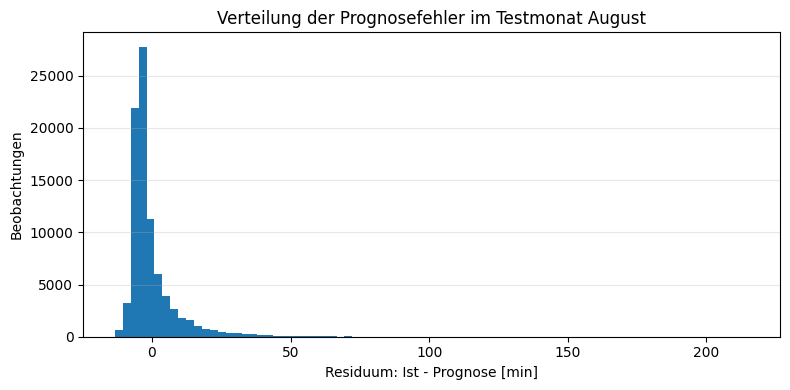

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_residuals, bins=80)
ax.set_title("Verteilung der Prognosefehler im Testmonat August")
ax.set_xlabel("Residuum: Ist - Prognose [min]")
ax.set_ylabel("Beobachtungen")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Die folgende Grafik vergleicht die tatsächlichen August-Verspätungen mit den Modellvorhersagen. Für die reine Visualisierung wird ein reproduzierbares Sample von höchstens 10.000 August-Beobachtungen verwendet; alle Kennzahlen oben basieren weiterhin auf allen August-Beobachtungen.

Die diagonale Linie `Ist = Prognose` ist keine Regressionsgerade und keine geschätzte Modellbeziehung. Sie zeigt ausschließlich theoretisch perfekte Vorhersagen.

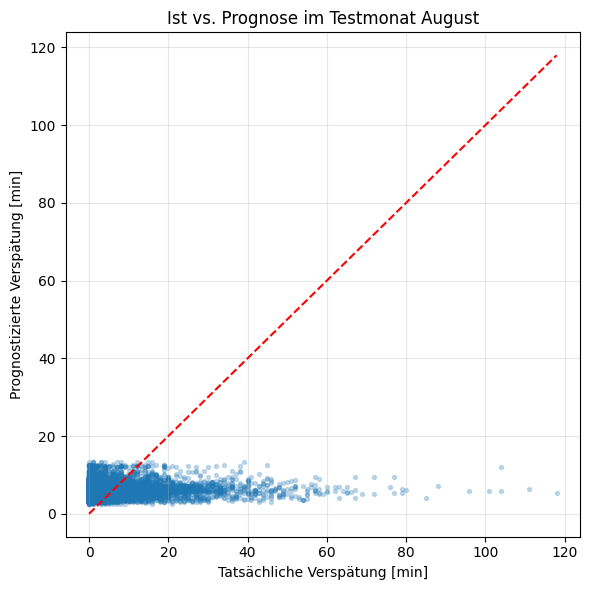

In [11]:
prediction_plot_data = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": final_test_predictions,
        "Residual": test_residuals,
    }
)

prediction_plot_sample = prediction_plot_data.sample(
    n=min(10_000, len(prediction_plot_data)),
    random_state=42,
)

axis_min = min(
    prediction_plot_sample["Actual"].min(),
    prediction_plot_sample["Predicted"].min(),
)
axis_max = max(
    prediction_plot_sample["Actual"].max(),
    prediction_plot_sample["Predicted"].max(),
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    prediction_plot_sample["Actual"],
    prediction_plot_sample["Predicted"],
    alpha=0.25,
    s=8,
)
ax.plot([axis_min, axis_max], [axis_min, axis_max], color="red", linestyle="--")
ax.set_title("Ist vs. Prognose im Testmonat August")
ax.set_xlabel("Tatsächliche Verspätung [min]")
ax.set_ylabel("Prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Die zweite Darstellung begrenzt ausschließlich den sichtbaren Wertebereich auf Beobachtungen bis zum 99. Perzentil der tatsächlichen Verspätungen. Die Datenbasis der Metriken bleibt unverändert der vollständige August-Testdatensatz.

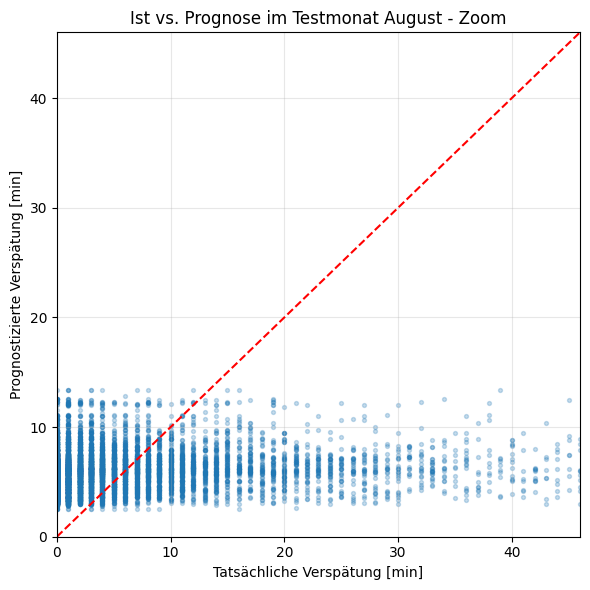

In [12]:
actual_p99 = y_test.quantile(0.99)
zoom_plot_data = prediction_plot_sample.loc[
    prediction_plot_sample["Actual"].between(0, actual_p99)
]

axis_min_zoom = 0
axis_max_zoom = max(
    zoom_plot_data["Actual"].max(),
    zoom_plot_data["Predicted"].max(),
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    zoom_plot_data["Actual"],
    zoom_plot_data["Predicted"],
    alpha=0.25,
    s=8,
)
ax.plot(
    [axis_min_zoom, axis_max_zoom],
    [axis_min_zoom, axis_max_zoom],
    color="red",
    linestyle="--",
)
ax.set_title("Ist vs. Prognose im Testmonat August - Zoom")
ax.set_xlabel("Tatsächliche Verspätung [min]")
ax.set_ylabel("Prognostizierte Verspätung [min]")
ax.set_xlim(axis_min_zoom, axis_max_zoom)
ax.set_ylim(axis_min_zoom, axis_max_zoom)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Die folgende Binning-Darstellung gruppiert August-Beobachtungen nach vorhergesagter Verspätung in Quantilgruppen. Sie dient nur als anschauliche Diagnose der Kalibrierung und wird nicht zur Modellanpassung verwendet.

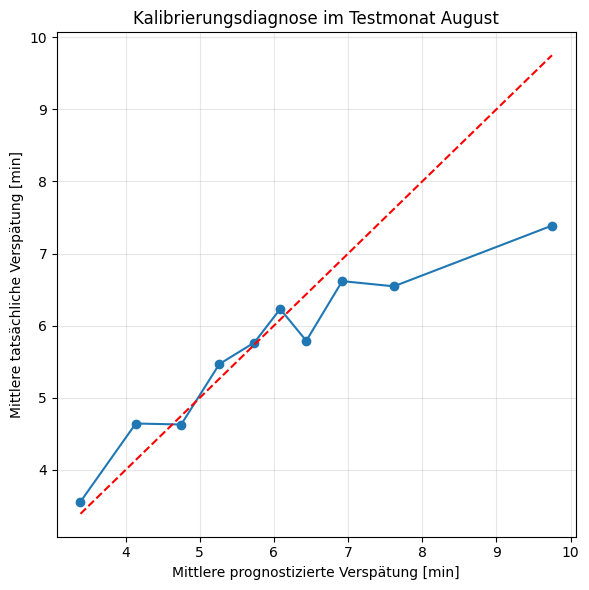

,Mean_Predicted,Mean_Actual,Observations
0,3.3930,3.5606,8618
1,4.1387,4.6444,8545
2,4.7503,4.6304,8577
3,5.2652,5.4684,8588
4,5.7363,5.7660,8667
5,6.0845,6.2312,8516
6,6.4362,5.7908,8572
7,6.9209,6.6174,8599
8,7.6167,6.5456,8604
9,9.7478,7.3867,8513


In [13]:
calibration_data = prediction_plot_data.copy()
calibration_data["Prediction Bin"] = pd.qcut(
    calibration_data["Predicted"],
    q=10,
    duplicates="drop",
)

calibration_summary = (
    calibration_data.groupby("Prediction Bin", observed=True)
    .agg(
        Mean_Predicted=("Predicted", "mean"),
        Mean_Actual=("Actual", "mean"),
        Observations=("Actual", "size"),
    )
    .reset_index(drop=True)
)

axis_min_calibration = min(
    calibration_summary["Mean_Predicted"].min(),
    calibration_summary["Mean_Actual"].min(),
)
axis_max_calibration = max(
    calibration_summary["Mean_Predicted"].max(),
    calibration_summary["Mean_Actual"].max(),
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    calibration_summary["Mean_Predicted"],
    calibration_summary["Mean_Actual"],
    marker="o",
)
ax.plot(
    [axis_min_calibration, axis_max_calibration],
    [axis_min_calibration, axis_max_calibration],
    color="red",
    linestyle="--",
)
ax.set_title("Kalibrierungsdiagnose im Testmonat August")
ax.set_xlabel("Mittlere prognostizierte Verspätung [min]")
ax.set_ylabel("Mittlere tatsächliche Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

calibration_summary.round(4)

## Abschluss der finalen Out-of-Sample-Evaluation

CatBoost wurde vor Betrachtung des August-Testdatensatzes festgelegt. Das Modell wurde auf November 2025 bis Juli 2026 neu trainiert. August wurde anschließend einmalig als unabhängiger Testzeitraum bewertet. Nach Betrachtung der August-Ergebnisse erfolgen keine Änderungen an Features, Hyperparametern oder Modellauswahl.

## 11. Post-hoc-Stabilitätsanalyse auf August

Die folgenden Analysen erfolgen erst nach Abschluss der finalen Out-of-Sample-Evaluation. Sie dienen nicht zur Modelloptimierung, sondern prüfen, ob zentrale Einflussmuster auch beim finalen Modell im August erkennbar bleiben.

Notebook 02 interpretiert ein Modell, das auf November 2025 bis Juni 2026 trainiert und auf Juli analysiert wurde. Notebook 03 betrachtet nach Abschluss der finalen Evaluation ein neu trainiertes Modell auf November 2025 bis Juli 2026 und bewertet dessen Verhalten auf August. Daher sind Juli- und August-Importance-Werte keine streng identischen Wiederholungsmessungen desselben Modells. Sie können qualitativ genutzt werden, um zeitliche Stabilität zentraler Muster einzuschätzen; daraus folgt keine formale Signifikanzbehauptung.

## 12. Gruppierte Permutation Importance auf August

Die Berechnung entspricht Notebook 02: Baseline ist das August-Test-R² des finalen CatBoost-Modells. Features innerhalb einer Gruppe werden mit derselben Zeilenpermutation verschoben. Die Analyse ist post hoc und wird nicht zur Anpassung des Modells verwendet.

In [14]:
X_test_interpretation = X_test_catboost.copy()
y_test_interpretation = y_test.copy()

posthoc_groups = {
    "Tageszeit": ["event_hour"],
    "Wochentag": ["event_weekday"],
    "Feiertag": ["is_public_holiday"],
    "Windgeschwindigkeit": ["ff_wind_speed_ms"],
    "Windrichtung": ["wind_direction_sin", "wind_direction_cos"],
    "Windböen": ["fx_wind_gust_ms"],
    "Temperatur": ["tu_temperature_c"],
    "Relative Luftfeuchtigkeit": ["tu_relative_humidity_pct"],
    "Niederschlagsmenge": ["rr_precipitation_mm"],
    "Niederschlagsindikator": ["rr_precipitation_indicator"],
    "Niederschlagsform": ["rr_precipitation_form"],
    "Niederschlag gesamt": [
        "rr_precipitation_mm",
        "rr_precipitation_indicator",
        "rr_precipitation_form",
    ],
}


def predict_catboost(model: CatBoostRegressor, X: pd.DataFrame) -> np.ndarray:
    prediction_pool = Pool(X, cat_features=categorical_features)
    return model.predict(prediction_pool)


def group_has_variation(X: pd.DataFrame, columns: list[str]) -> bool:
    return X[columns].drop_duplicates().shape[0] > 1


def calculate_grouped_permutation_importance(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    y: pd.Series,
    groups: dict[str, list[str]],
    baseline_r2: float,
    constant_status: str,
    n_repeats: int = 10,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    rows = []

    for factor, columns in groups.items():
        if not group_has_variation(X, columns):
            rows.append(
                {
                    "Factor": factor,
                    "Importance Mean": np.nan,
                    "Importance Std": np.nan,
                    "Status": constant_status,
                }
            )
            continue

        importance_values = []

        for _ in range(n_repeats):
            X_permuted = X.copy()
            permutation = rng.permutation(len(X_permuted))

            for column in columns:
                X_permuted[column] = X_permuted[column].to_numpy()[permutation]

            permuted_predictions = predict_catboost(model, X_permuted)
            permuted_r2 = r2_score(y, permuted_predictions)
            importance_values.append(baseline_r2 - permuted_r2)

        rows.append(
            {
                "Factor": factor,
                "Importance Mean": float(np.mean(importance_values)),
                "Importance Std": float(np.std(importance_values, ddof=1)),
                "Status": "ok",
            }
        )

    return (
        pd.DataFrame(rows)
        .assign(sort_importance=lambda df: df["Importance Mean"].fillna(-np.inf))
        .sort_values("sort_importance", ascending=False)
        .drop(columns="sort_importance")
        .reset_index(drop=True)
    )


august_permutation_importance = calculate_grouped_permutation_importance(
    model=final_catboost_model,
    X=X_test_interpretation,
    y=y_test_interpretation,
    groups=posthoc_groups,
    baseline_r2=catboost_test_r2,
    constant_status="konstant im Testmonat",
    n_repeats=10,
    random_state=42,
)

august_permutation_importance.round(4)

,Factor,Importance Mean,Importance Std,Status
0,Relative Luftfeuchtigkeit,0.0403,0.0008,ok
1,Wochentag,0.0127,0.0008,ok
2,Tageszeit,0.0124,0.0011,ok
3,Temperatur,0.0119,0.0010,ok
4,Niederschlag gesamt,0.0010,0.0001,ok
5,Windrichtung,0.0009,0.0003,ok
6,Niederschlagsform,0.0004,0.0000,ok
7,Niederschlagsmenge,0.0004,0.0000,ok
8,Niederschlagsindikator,0.0002,0.0000,ok
9,Windböen,0.0002,0.0000,ok


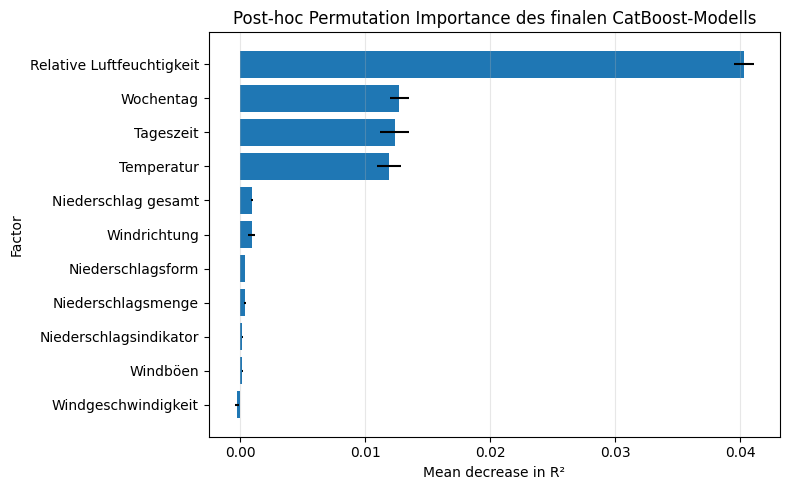

,Factor,Status
11,Feiertag,konstant im Testmonat


,Factor,Importance Mean,Importance Std,Status
0,Relative Luftfeuchtigkeit,0.0403,0.0008,ok
1,Wochentag,0.0127,0.0008,ok
2,Tageszeit,0.0124,0.0011,ok
3,Temperatur,0.0119,0.0010,ok
4,Niederschlag gesamt,0.0010,0.0001,ok
5,Windrichtung,0.0009,0.0003,ok
6,Niederschlagsform,0.0004,0.0000,ok
7,Niederschlagsmenge,0.0004,0.0000,ok
8,Niederschlagsindikator,0.0002,0.0000,ok
9,Windböen,0.0002,0.0000,ok


In [15]:
plot_data = august_permutation_importance.loc[
    august_permutation_importance["Status"] == "ok"
].sort_values(
    "Importance Mean",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    plot_data["Factor"],
    plot_data["Importance Mean"],
    xerr=plot_data["Importance Std"],
)
ax.set_title("Post-hoc Permutation Importance des finalen CatBoost-Modells")
ax.set_xlabel("Mean decrease in R²")
ax.set_ylabel("Factor")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

constant_groups = august_permutation_importance.loc[
    august_permutation_importance["Status"] != "ok",
    ["Factor", "Status"],
]

if not constant_groups.empty:
    display(constant_groups)

august_permutation_importance.round(4)

## 13. Ausgewählte PDPs auf August

Die folgenden PDPs wiederholen nur zentrale Faktoren: Tageszeit, Wochentag, Temperatur und relative Luftfeuchtigkeit. Sie dienen ausschließlich der post-hoc Stabilitätsprüfung und nicht der Modellanpassung. Die Achse zeigt jeweils die durchschnittlich prognostizierte Verspätung des finalen CatBoost-Modells.

In [16]:
def calculate_numeric_partial_dependence(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    feature: str,
    values: np.ndarray,
) -> pd.DataFrame:
    rows = []

    for value in values:
        X_modified = X.copy()
        X_modified[feature] = value
        mean_prediction = float(np.mean(predict_catboost(model, X_modified)))
        rows.append(
            {
                "Feature": feature,
                "Value": value,
                "Mean Prediction [min]": mean_prediction,
            }
        )

    return pd.DataFrame(rows)


def calculate_categorical_partial_dependence(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    feature: str,
    values: list,
    display_values: list | None = None,
) -> pd.DataFrame:
    if display_values is None:
        display_values = values

    rows = []

    for assigned_value, display_value in zip(values, display_values):
        X_modified = X.copy()
        X_modified[feature] = assigned_value
        mean_prediction = float(np.mean(predict_catboost(model, X_modified)))
        rows.append(
            {
                "Feature": feature,
                "Value": display_value,
                "Assigned Value": assigned_value,
                "Mean Prediction [min]": mean_prediction,
            }
        )

    return pd.DataFrame(rows)


def evenly_spaced_quantile_grid(
    series: pd.Series,
    lower_quantile: float = 0.05,
    upper_quantile: float = 0.95,
    n_values: int = 20,
) -> np.ndarray:
    numeric_series = pd.to_numeric(series, errors="coerce").dropna()
    lower = numeric_series.quantile(lower_quantile)
    upper = numeric_series.quantile(upper_quantile)

    if np.isclose(lower, upper):
        return np.array([float(lower)])

    return np.linspace(lower, upper, n_values)


def sorted_observed_values(series: pd.Series) -> list:
    values = pd.Series(series.dropna().unique()).tolist()

    def sort_key(value):
        try:
            return (0, float(value))
        except (TypeError, ValueError):
            return (1, str(value))

    return sorted(values, key=sort_key)


def common_observed_values(
    train_series: pd.Series,
    test_series: pd.Series,
) -> list:
    train_values = set(sorted_observed_values(train_series))
    test_values = set(sorted_observed_values(test_series))
    return sorted_observed_values(pd.Series(list(train_values & test_values)))

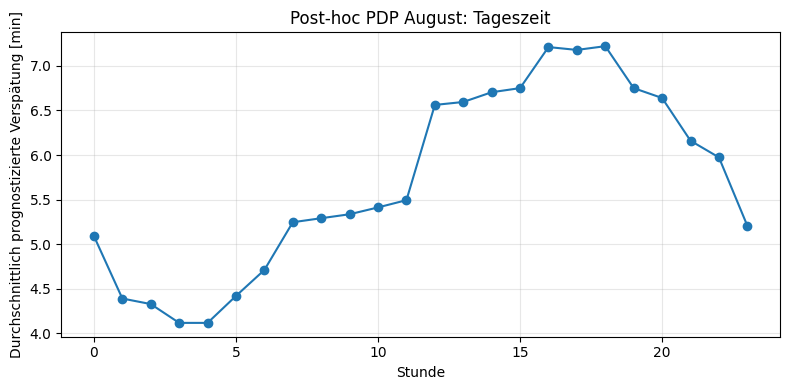

,Feature,Value,Assigned Value,Mean Prediction [min]
0,event_hour,0,0,5.0895
1,event_hour,1,1,4.3886
2,event_hour,2,2,4.3264
3,event_hour,3,3,4.1151
4,event_hour,4,4,4.1151
5,event_hour,5,5,4.4178
6,event_hour,6,6,4.7095
7,event_hour,7,7,5.2453
8,event_hour,8,8,5.2904
9,event_hour,9,9,5.3349


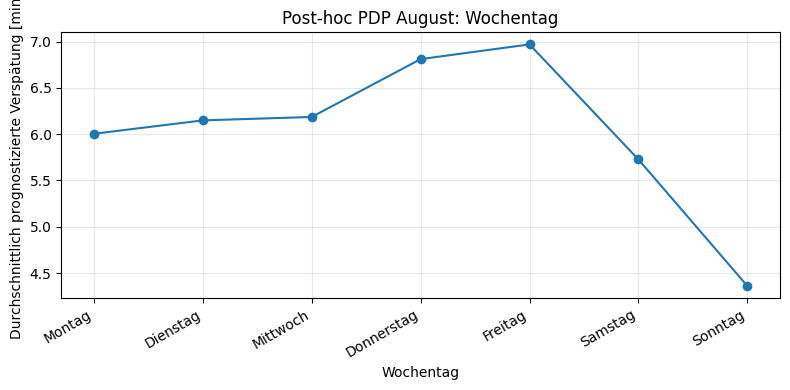

,Feature,Value,Assigned Value,Mean Prediction [min]
0,event_weekday,0,0,6.0049
1,event_weekday,1,1,6.1494
2,event_weekday,2,2,6.1865
3,event_weekday,3,3,6.8117
4,event_weekday,4,4,6.9705
5,event_weekday,5,5,5.7270
6,event_weekday,6,6,4.3600


In [17]:
event_hour_values = common_observed_values(
    X_final_train_catboost["event_hour"],
    X_test_interpretation["event_hour"],
)
event_hour_display_values = [int(value) for value in event_hour_values]

event_hour_pd = calculate_categorical_partial_dependence(
    model=final_catboost_model,
    X=X_test_interpretation,
    feature="event_hour",
    values=event_hour_values,
    display_values=event_hour_display_values,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_hour_pd["Value"], event_hour_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Post-hoc PDP August: Tageszeit")
ax.set_xlabel("Stunde")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(event_hour_pd.round(4))

event_weekday_values = common_observed_values(
    X_final_train_catboost["event_weekday"],
    X_test_interpretation["event_weekday"],
)
event_weekday_display_values = [int(value) for value in event_weekday_values]
weekday_labels = [
    "Montag",
    "Dienstag",
    "Mittwoch",
    "Donnerstag",
    "Freitag",
    "Samstag",
    "Sonntag",
]

event_weekday_pd = calculate_categorical_partial_dependence(
    model=final_catboost_model,
    X=X_test_interpretation,
    feature="event_weekday",
    values=event_weekday_values,
    display_values=event_weekday_display_values,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_weekday_pd["Value"], event_weekday_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Post-hoc PDP August: Wochentag")
ax.set_xlabel("Wochentag")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.set_xticks(event_weekday_display_values)
ax.set_xticklabels(
    [weekday_labels[value] for value in event_weekday_display_values],
    rotation=30,
    ha="right",
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

event_weekday_pd.round(4)

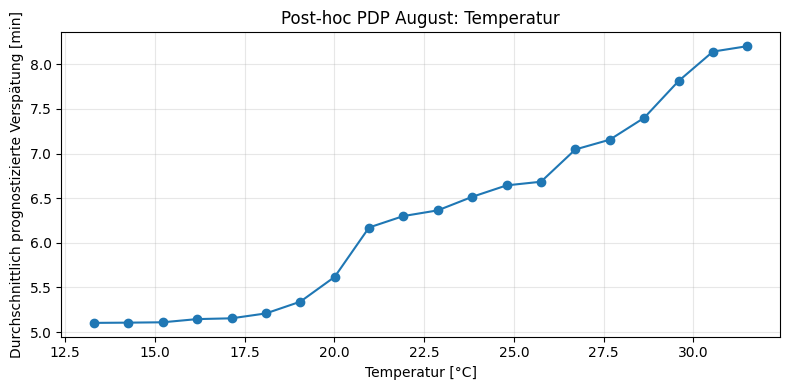

,Feature,Value,Mean Prediction [min]
0,tu_temperature_c,13.3000,5.1027
1,tu_temperature_c,14.2579,5.1054
2,tu_temperature_c,15.2158,5.1094
3,tu_temperature_c,16.1737,5.1452
4,tu_temperature_c,17.1316,5.1539
5,tu_temperature_c,18.0895,5.2088
6,tu_temperature_c,19.0474,5.3402
7,tu_temperature_c,20.0053,5.6183
8,tu_temperature_c,20.9632,6.1718
9,tu_temperature_c,21.9211,6.3002


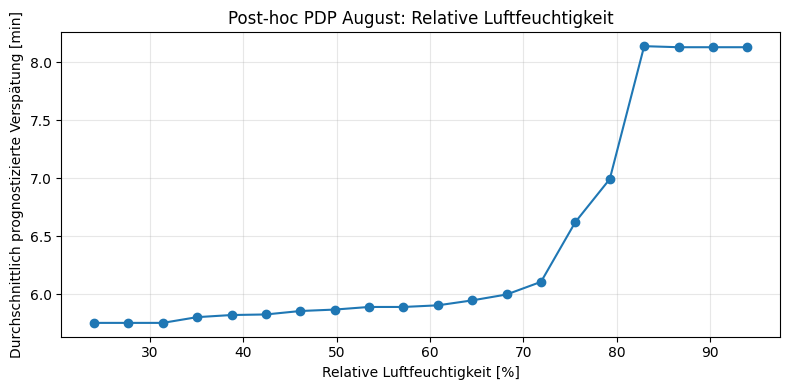

,Feature,Value,Mean Prediction [min]
0,tu_relative_humidity_pct,24.0000,5.7543
1,tu_relative_humidity_pct,27.6842,5.7543
2,tu_relative_humidity_pct,31.3684,5.7543
3,tu_relative_humidity_pct,35.0526,5.8038
4,tu_relative_humidity_pct,38.7368,5.8221
5,tu_relative_humidity_pct,42.4211,5.8270
6,tu_relative_humidity_pct,46.1053,5.8567
7,tu_relative_humidity_pct,49.7895,5.8691
8,tu_relative_humidity_pct,53.4737,5.8917
9,tu_relative_humidity_pct,57.1579,5.8917


In [18]:
temperature_grid = evenly_spaced_quantile_grid(X_test_interpretation["tu_temperature_c"])
temperature_pd = calculate_numeric_partial_dependence(
    model=final_catboost_model,
    X=X_test_interpretation,
    feature="tu_temperature_c",
    values=temperature_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temperature_pd["Value"], temperature_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Post-hoc PDP August: Temperatur")
ax.set_xlabel("Temperatur [°C]")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(temperature_pd.round(4))

humidity_grid = evenly_spaced_quantile_grid(X_test_interpretation["tu_relative_humidity_pct"])
humidity_pd = calculate_numeric_partial_dependence(
    model=final_catboost_model,
    X=X_test_interpretation,
    feature="tu_relative_humidity_pct",
    values=humidity_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(humidity_pd["Value"], humidity_pd["Mean Prediction [min]"], marker="o")
ax.set_title("Post-hoc PDP August: Relative Luftfeuchtigkeit")
ax.set_xlabel("Relative Luftfeuchtigkeit [%]")
ax.set_ylabel("Durchschnittlich prognostizierte Verspätung [min]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

humidity_pd.round(4)